# Sanity Check
This notebook builds the master database and verifies that it was built correctly by running a series of consistency checks.

## Database Build


Build the financial database using the pipeline in `src/db_building`. 

In [21]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.db_building.build_db import build_database
from notebooks.params import MASTER_TICKERS, START_DATE_STR, END_DATE_STR, OUT_DIR

out_path = OUT_DIR / "stages" / "panel_raw.parquet"

if out_path.exists():
    print(f"Database already exists at {out_path}")
else:
    build_database(
        tickers=MASTER_TICKERS,
        start=START_DATE_STR,
        end=END_DATE_STR,
        out_path=out_path,
        force_refresh_prices=False,
        force_refresh_macro=False,
    )


Database already exists at /Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/datasets/master_45t_20y/stages/panel_raw.parquet


Save a snapshot of the config used to create the database.

In [ ]:
from src.config.io import save_run_snapshot
from notebooks.params import CFG, MASTER_TICKERS, OUT_DIR

run_snapshot = dict(CFG)
run_snapshot["tickers_count"] = len(MASTER_TICKERS)
save_run_snapshot(run_snapshot, OUT_DIR)

PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/datasets/master_45t_20y/config.yaml')

## Database Loading

Load the dataset from disk. This should complete without errors.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

df = pd.read_parquet(out_path)

Preview the first rows to confirm columns and dtypes look reasonable.

In [23]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

df.head()

,date,open,high,low,close,adj_close,volume,sma_200,price_sma_200,mom_3m,mom_6m,mom_12m,volatility_20d,volatility_60d,ret_1d,ret_5d,ret_21d,roe,roa,operating_margin,gross_margin,revenue_growth_yoy,earnings_growth_yoy,debt_to_equity,interest_coverage,asset_turnover,fcf_assets,effective_date,macro_effective_date,CPIAUCSL,DGS10,DGS2,INDPRO,STLFSI4,ticker,sector
0,2006-01-03,2.585000,2.669643,2.580357,2.669643,2.239734,807234400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.057594,0.037226,0.113649,0.281403,NaN,NaN,NaN,6.966667,0.318414,0.056792,2005-11-29,NaT,NaN,NaN,NaN,NaN,NaN,AAPL,Technology
1,2006-01-03,37.270000,37.389999,36.650002,37.360001,16.871881,1880300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.043072,0.010763,0.187200,0.623798,NaN,NaN,1.308514,4296.551724,0.092558,0.002809,2005-11-29,NaT,NaN,NaN,NaN,NaN,NaN,AEP,Utilities
2,2006-01-03,27.270000,27.309999,26.660000,27.299999,19.961164,3653700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004499,-0.002375,0.171821,0.657717,NaN,NaN,0.784785,10.300083,0.030134,0.008251,2005-11-29,NaT,NaN,NaN,NaN,NaN,NaN,AMT,Real Estate
3,2006-01-03,2.373500,2.392500,2.312500,2.379000,2.379000,151644000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,0.010593,0.029602,0.092034,NaN,NaN,255.000000,2.500000,0.656073,0.027189,2005-11-29,NaT,NaN,NaN,NaN,NaN,NaN,AMZN,Consumer Discretionary
4,2006-01-03,51.700001,52.580002,51.049999,52.580002,38.855633,7825700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005-11-29,NaT,NaN,NaN,NaN,NaN,NaN,AXP,Financials


## Initial Overview

### Shape, range and tickers

Check dataset size, expected date range (start of 2006 to end of 2025), and presence of all 45 tickers.

In [24]:
print("Shape:", df.shape)
print("Date Range:", df["date"].min().date(), "->", df["date"].max().date())
print("Number of Tickers:", df["ticker"].nunique())
print("Tickers:", sorted(df["ticker"].unique()))

Shape: (221854, 36)
Date Range: 2006-01-03 -> 2025-12-30
Number of Tickers: 45
Tickers: ['AAPL', 'ABBV', 'AEP', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'CAT', 'COP', 'COST', 'CVX', 'D', 'DUK', 'EQIX', 'GE', 'GOOGL', 'GS', 'JNJ', 'JPM', 'KO', 'MCD', 'META', 'MMM', 'MRK', 'MS', 'MSFT', 'NEE', 'NKE', 'NVDA', 'PEP', 'PFE', 'PG', 'PLD', 'PSA', 'SBUX', 'SHEL', 'SO', 'SPG', 'TSLA', 'TTE', 'UNH', 'UNP', 'WMT', 'XOM']


### Date continuity and frequency

Check per-ticker date gaps to confirm daily coverage and spot unusually long breaks.

In [25]:
df_sorted = df.sort_values(["ticker", "date"])
gaps = df_sorted.groupby("ticker")["date"].diff().dt.days

print("Gap (days) distribution:")
print(gaps.value_counts().sort_index().head(10))

largest_gaps = gaps.groupby(df_sorted["ticker"]).max().sort_values(ascending=False)
print("Largest gaps per ticker (days):")
display(largest_gaps.head(10))

suspicious = gaps[gaps > 4]
print("Gaps > 4 days:", suspicious.count())

Gap (days) distribution:
date
1.0    173593
2.0      2212
3.0     40095
4.0      5823
5.0        86
Name: count, dtype: int64
Largest gaps per ticker (days):


ticker
AAPL    5.0
MMM     5.0
MS      5.0
MSFT    5.0
NEE     5.0
NKE     5.0
NVDA    5.0
PEP     5.0
PFE     5.0
PG      5.0
Name: date, dtype: float64

Gaps > 4 days: 86


There are 86 dates with a 5-days gap in between them. In a 20 year timespan this is perfectly possible, so we continue.

### Columns

Verify that the core OHLCV fields, `ticker`, and `date` are present and non-null.

In [26]:
expected_price_cols = ["open","high","low","close","adj_close","volume","ticker","date"]
missing = [c for c in expected_price_cols if c not in df.columns]
print("missing core cols:", missing)


missing core cols: []


Count the total number of columns and the distribution of dtypes.

In [27]:
print("num columns:", len(df.columns))
print(df.dtypes.value_counts())

num columns: 36
float64           30
datetime64[ns]     3
object             2
int64              1
Name: count, dtype: int64


Confirm the object columns (`ticker` and `sector`) and the datetime columns (the main `date` plus two auxiliary date fields).

In [28]:
column_types = df.dtypes
obj_cols = column_types[column_types == "object"]
date_cols = column_types[column_types == "datetime64[ns]"]

print("Object cols:", obj_cols.index.tolist())
print("Date cols:", date_cols.index.tolist())

Object cols: ['ticker', 'sector']
Date cols: ['date', 'effective_date', 'macro_effective_date']


List the numeric columns to confirm which features are treated as numeric inputs.

In [29]:
df.select_dtypes(include=["number"]).columns.tolist()

['open',
 'high',
 'low',
 'close',
 'adj_close',
 'volume',
 'sma_200',
 'price_sma_200',
 'mom_3m',
 'mom_6m',
 'mom_12m',
 'volatility_20d',
 'volatility_60d',
 'ret_1d',
 'ret_5d',
 'ret_21d',
 'roe',
 'roa',
 'operating_margin',
 'gross_margin',
 'revenue_growth_yoy',
 'earnings_growth_yoy',
 'debt_to_equity',
 'interest_coverage',
 'asset_turnover',
 'fcf_assets',
 'CPIAUCSL',
 'DGS10',
 'DGS2',
 'INDPRO',
 'STLFSI4']

### Uniqueness and Duplicates

The `(date, ticker)` pair must be unique.

In [30]:
dups = df.duplicated(subset=["date", "ticker"]).sum()
print("duplicate rows on (date,ticker):", dups)

if dups > 0:
    display(df[df.duplicated(subset=["date","ticker"], keep=False)].head(20))


duplicate rows on (date,ticker): 0


### Panel structure

Validate the panel structure to confirm the long format (one row per `date` and `ticker`).

In [ ]:
df[["date", "ticker"]].drop_duplicates().head(42)

,date,ticker
0,2006-01-03,AAPL
1,2006-01-03,AEP
2,2006-01-03,AMT
3,2006-01-03,AMZN
4,2006-01-03,AXP
5,2006-01-03,BA
6,2006-01-03,BAC
7,2006-01-03,CAT
8,2006-01-03,COP
9,2006-01-03,COST


### Panel Completeness

Each trading day should contain the full cross section of tickers (no missing tickers for a given date).

In [34]:
counts = df.groupby("date")["ticker"].nunique()
print("min tickers/day:", counts.min())
print("max tickers/day:", counts.max())
print("days with missing tickers:", (counts < counts.max()).sum())

# show worst days
display(counts[counts < counts.max()].head(10))

min tickers/day: 42
max tickers/day: 45
days with missing tickers: 1761


date
2006-01-03    42
2006-01-04    42
2006-01-05    42
2006-01-06    42
2006-01-09    42
2006-01-10    42
2006-01-11    42
2006-01-12    42
2006-01-13    42
2006-01-17    42
Name: ticker, dtype: int64

It is expected that a few tickers (ABBV, META, TSLA) are missing at the very beginning of the
window because their IPO dates are later than the master start date. This is normal for a long
historical master panel and will be handled when slicing shorter views. The table below reports the first available trading day for tickers whose coverage is below 100%.
This confirms which assets entered the master panel after the global start date.

In [36]:
coverage = df.groupby("ticker")["date"].nunique()
total_days = df["date"].nunique()
partial = coverage[coverage < total_days].index
first_dates = df.groupby("ticker")["date"].min()
display(first_dates.loc[partial].sort_values())


ticker
TSLA   2010-06-29
META   2012-05-18
ABBV   2013-01-02
Name: date, dtype: datetime64[ns]

### Per-Ticker Coverage Ratio


Quantify coverage per ticker relative to the full date range. This flags tickers with shorter histories
or data gaps in the raw panel.

In [38]:
total_days = df["date"].nunique()
coverage = df.groupby("ticker")["date"].nunique().sort_values()
coverage_ratio = (coverage / total_days).sort_values()
display(coverage_ratio.head(10))
print("Min coverage ratio:", f"{coverage_ratio.min():.2%}")


ticker
ABBV    0.649901
META    0.680716
TSLA    0.775547
AMT     1.000000
AMZN    1.000000
AXP     1.000000
BA      1.000000
BAC     1.000000
CAT     1.000000
COP     1.000000
Name: date, dtype: float64

Min coverage ratio: 64.99%


After checking daily ticker counts, summarize per-ticker coverage (first/last date and row count) to confirm consistent history.

In [39]:
# Compare each ticker's first/last date
coverage = df.groupby("ticker")["date"].agg(["min","max","count"]).sort_index()
coverage

,min,max,count
ticker,,,
AAPL,2006-01-03,2025-12-30,5030
ABBV,2013-01-02,2025-12-30,3269
AEP,2006-01-03,2025-12-30,5030
AMT,2006-01-03,2025-12-30,5030
AMZN,2006-01-03,2025-12-30,5030
AXP,2006-01-03,2025-12-30,5030
BA,2006-01-03,2025-12-30,5030
BAC,2006-01-03,2025-12-30,5030
CAT,2006-01-03,2025-12-30,5030


5030 trading days are available, as shown above. As expected, besides the 3 tickers with an IPO date later than the master start date, the rest all have consistent history. We visualize yearly availability per ticker to confirm IPO-driven coverage gaps in the master panel.

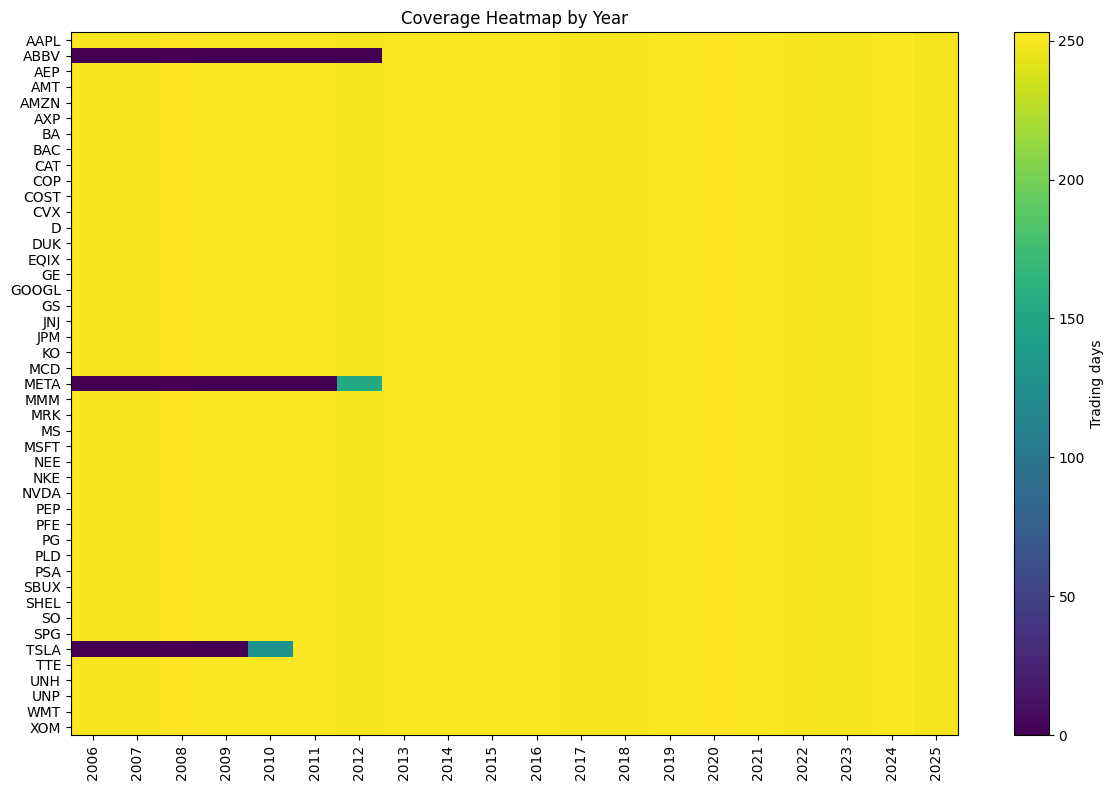

In [67]:
import numpy as np

cov_year = (
    df.assign(year=df["date"].dt.year)
      .groupby(["ticker", "year"])["date"]
      .nunique()
)
cov_pivot = cov_year.unstack("year").fillna(0)

plt.figure(figsize=(12, 8))
plt.imshow(cov_pivot.values, aspect="auto", cmap="viridis")
plt.colorbar(label="Trading days")
plt.yticks(range(len(cov_pivot.index)), cov_pivot.index)
plt.xticks(range(len(cov_pivot.columns)), cov_pivot.columns, rotation=90)
plt.title("Coverage Heatmap by Year")
plt.tight_layout()
plt.show()


### Sector Coverage


Verify that sector labels are present and that no tickers are mapped to `Unknown`.

In [37]:
sector_counts = df["sector"].value_counts(dropna=False)
display(sector_counts)
print("Unknown sector rows:", int((df["sector"] == "Unknown").sum()))


sector
Utilities                 25150
Real Estate               25150
Financials                25150
Industrials               25150
Energy                    25150
Consumer Staples          25150
Consumer Discretionary    24021
Technology                23544
Health Care               23389
Name: count, dtype: int64

Unknown sector rows: 0


### NaN rates

Plot NaN rates to make small differences across features more visible.


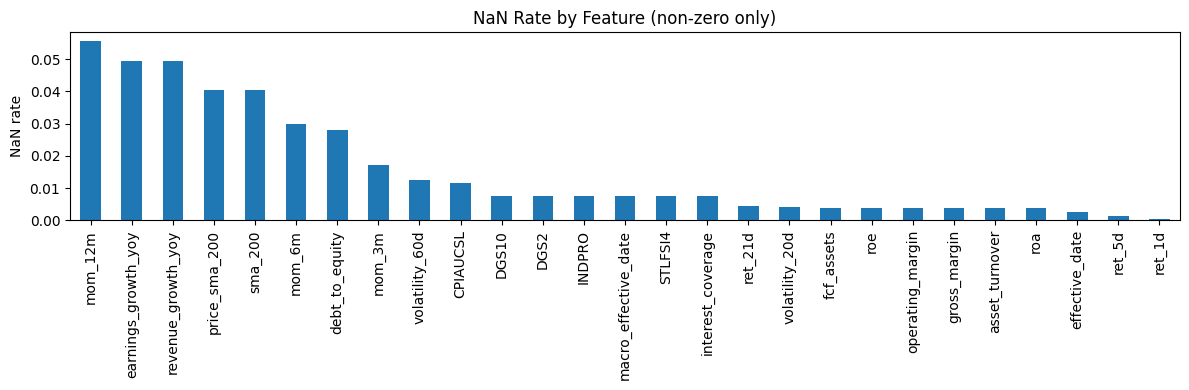

mom_12m                0.055577
earnings_growth_yoy    0.049402
revenue_growth_yoy     0.049402
price_sma_200          0.040567
sma_200                0.040567
mom_6m                 0.030020
debt_to_equity         0.028158
mom_3m                 0.017241
volatility_60d         0.012373
CPIAUCSL               0.011629
dtype: float64

In [ ]:
nan_rates = df.isna().mean().sort_values(ascending=False)
top = nan_rates[nan_rates > 0]
plt.figure(figsize=(12, 4))
top.plot(kind="bar")
plt.title("NaN Rate by Feature (non-zero only)")
plt.ylabel("NaN rate")
plt.tight_layout()
plt.show()

above_one_percent = nan_rates[nan_rates > 0.01]
display(above_one_percent)


NaN rates are low overall. The small non-zero NaN mass (max ~5%) appears in rolling technical
features that require a minimum lookback window, which is expected at the start of each series.
Macro and fundamentals contribute relatively few missing values at this stage, so the raw panel
looks clean. Any residual gaps will be handled in preprocessing.


### Leak Checks

Check for look-ahead leakage by verifying that any effective dates are not later than the observation date.

In [70]:
if "macro_effective_date" in df.columns:
    leak_macro = (df["macro_effective_date"] > df["date"]).sum()
    print("Macro effective_date > date:", int(leak_macro))
else:
    print("No macro_effective_date column found.")

if "effective_date" in df.columns:
    leak_funds = (df["effective_date"] > df["date"]).sum()
    print("Funds effective_date > date:", int(leak_funds))
else:
    print("No effective_date column found.")


Macro effective_date > date: 0
Funds effective_date > date: 0


For each observation, firm-level fundamentals and macroeconomical data are only used after their public release date. This is enforced by requiring the effective publication date to be less than or equal to the observation date, thereby preventing any form of lookahead bias. NaN in effective_date/macro_effective_date are expected before the first release; it does not indicate leakage.

### Prices

Sanity-check price fields: no negative volume or non-positive prices, and review return distribution for extreme jumps.

volume negative: 0
adj_close <= 0: 0


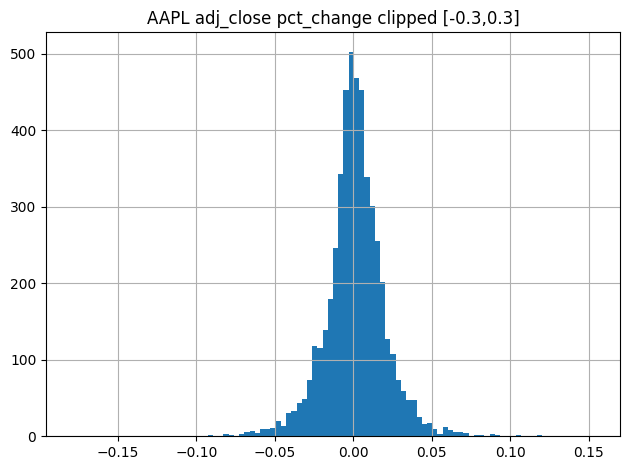

In [50]:
print("volume negative:", (df["volume"] < 0).sum())
print("adj_close <= 0:", (df["adj_close"] <= 0).sum())

# spot check extreme jumps (split adjustments etc.)
ticker = sorted(df["ticker"].unique())[0]
t = df[df["ticker"]==ticker].sort_values("date")
rets = t["adj_close"].pct_change()

plt.figure()
rets.clip(-0.3, 0.3).hist(bins=100)
plt.title(f"{ticker} adj_close pct_change clipped [-0.3,0.3]")
plt.tight_layout()
plt.show()


## Technical Data

### Returns Consistency

Validate that precomputed returns match `adj_close.pct_change()` with the expected shift. We check more than one ticker to avoid a single-case false positive.

In [51]:
tickers = sorted(df["ticker"].unique())
sample = tickers[:3] if len(tickers) >= 3 else tickers

for tkr in sample:
    t = df[df["ticker"] == tkr].sort_values("date")
    true_ret = t["adj_close"].pct_change(1)
    expected = true_ret.shift(1)
    diff = (t["ret_1d"] - expected).abs().dropna()
    print(f"{tkr} | mean abs diff: {diff.mean():.6f} | max abs diff: {diff.max():.6f}")


AAPL | mean abs diff: 0.000000 | max abs diff: 0.000000
ABBV | mean abs diff: 0.000000 | max abs diff: 0.000000
AEP | mean abs diff: 0.000000 | max abs diff: 0.000000


### Momentum Lag Consistency


Verify that momentum features apply the one-month skip and a final shift to avoid look-ahead.
The check recomputes momentum from `adj_close` and compares against stored values.

In [52]:
tdm = 21
sample = tickers[:3] if len(tickers) >= 3 else tickers

for tkr in sample:
    t = df[df["ticker"] == tkr].sort_values("date")
    for col, months in [("mom_3m", 3), ("mom_6m", 6), ("mom_12m", 12)]:
        if col not in t.columns:
            continue
        expected = t["adj_close"].shift(tdm + 1) / t["adj_close"].shift(tdm + months * tdm + 1) - 1
        diff = (t[col] - expected).abs().dropna()
        if diff.empty:
            print(f"{tkr} | {col} | no comparable rows")
        else:
            print(f"{tkr} | {col} | mean abs diff: {diff.mean():.6f} | max abs diff: {diff.max():.6f}")


AAPL | mom_3m | mean abs diff: 0.000000 | max abs diff: 0.000000
AAPL | mom_6m | mean abs diff: 0.000000 | max abs diff: 0.000000
AAPL | mom_12m | mean abs diff: 0.000000 | max abs diff: 0.000000
ABBV | mom_3m | mean abs diff: 0.000000 | max abs diff: 0.000000
ABBV | mom_6m | mean abs diff: 0.000000 | max abs diff: 0.000000
ABBV | mom_12m | mean abs diff: 0.000000 | max abs diff: 0.000000
AEP | mom_3m | mean abs diff: 0.000000 | max abs diff: 0.000000
AEP | mom_6m | mean abs diff: 0.000000 | max abs diff: 0.000000
AEP | mom_12m | mean abs diff: 0.000000 | max abs diff: 0.000000


### Trend, Momentum, and Volatility Checks


Confirm trend and volatility indicators are properly lagged and that longer windows have more NaNs (e.g., `sma_200` and `volatility_60d` vs shorter windows).


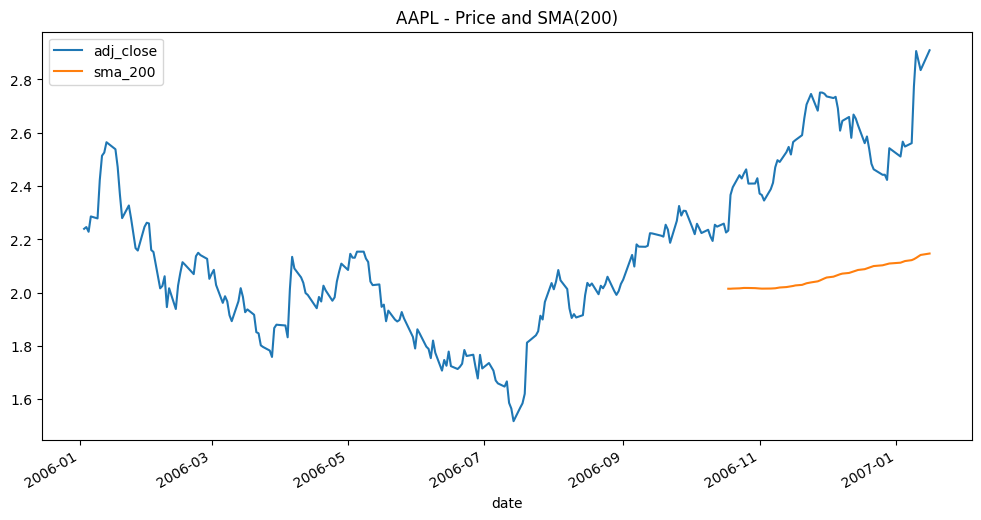

In [53]:
cols = [
    "adj_close",
    "sma_200",
]

aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl[cols].iloc[:260].plot(figsize=(12,6))
plt.title("AAPL - Price and SMA(200)")
plt.show()


In [54]:
tech_cols = [
    "sma_200",
    "price_sma_200",
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "volatility_20d",
    "volatility_60d",
]
tech_cols = [c for c in tech_cols if c in df.columns]
if tech_cols:
    na_rates = df[tech_cols].isna().mean().sort_values(ascending=False)
    display(na_rates)
else:
    print("No technical columns found.")


mom_12m           0.055577
sma_200           0.040567
price_sma_200     0.040567
mom_6m            0.030020
mom_3m            0.017241
volatility_60d    0.012373
volatility_20d    0.004260
dtype: float64

### Momentum and Volatility Ranges


Check distribution ranges to flag extreme values or scale issues. Momentum should be centered around small percentages, while volatility should be strictly non-negative and relatively small in magnitude.


In [55]:
cols = [
    "mom_3m",
    "mom_6m",
    "mom_12m",
    "price_sma_200",
    "volatility_20d",
    "volatility_60d",
]
cols = [c for c in cols if c in df.columns]
for c in cols:
    s = df[c].dropna()
    if not s.empty:
        q = s.quantile([0.01, 0.5, 0.99])
        print(c, "quantiles:", q.to_dict())


mom_3m quantiles: {0.01: -0.3332147666241928, 0.5: 0.03611025438904747, 0.99: 0.4679731727870842}
mom_6m quantiles: {0.01: -0.4332048387392623, 0.5: 0.07001704975198597, 0.99: 0.7805153736062858}
mom_12m quantiles: {0.01: -0.5232819104646211, 0.5: 0.13523449940680587, 0.99: 1.4221042141297493}
price_sma_200 quantiles: {0.01: 0.6487705749717363, 0.5: 1.0535511021193131, 0.99: 1.4626537023977417}
volatility_20d quantiles: {0.01: 0.00494365637075558, 0.5: 0.013233754639203052, 0.99: 0.06481205706985861}
volatility_60d quantiles: {0.01: 0.006037364850135165, 0.5: 0.013921510075161302, 0.99: 0.05950194408720663}


The quantile ranges for momentum, trend, and volatility are consistent with expectations for a
20-year equity panel: multi-month momentum can reach large positive values for strong uptrends,
while the lower tail captures drawdowns; `price_sma_200` is centered slightly above 1 and drops
below 1 in bear regimes; and daily volatility sits in a low single-digit range with higher tails
during stress. These magnitudes suggest the technical features are well-scaled and plausible.


In [56]:
for c in ["volatility_20d", "volatility_60d"]:
    if c in df.columns:
        neg = (df[c] < 0).sum()
        print(f"{c} negative values: {neg}")


volatility_20d negative values: 0
volatility_60d negative values: 0


Quick recap: technical features look consistent across returns, momentum, trend, and volatility checks.


## Fundamental Data

### Quarterly update check

Fundamental features should update quarterly and be forward-filled after a reporting lag. We verify piecewise-constancy between effective dates and sample segments to confirm values remain stable within each interval.


In [75]:
# Check that fundamentals are piecewise-constant between effective dates (forward-fill with lag)
fund_cols = [
    "operating_margin",
    "gross_margin",
    "roe",
    "roa",
    "revenue_growth_yoy",
    "earnings_growth_yoy",
    "debt_to_equity",
    "interest_coverage",
    "asset_turnover",
    "fcf_assets"
]
fund_cols = [c for c in fund_cols if c in df.columns]

if not fund_cols:
    print("No fundamental columns found.")
else:
    # Use effective_date if present, otherwise approximate by change points in the first available fundamental
    ed_col = "effective_date" if "effective_date" in df.columns else None
    for tkr, t in df.sort_values(["ticker", "date"]).groupby("ticker"):
        t = t.copy()
        if ed_col:
            t[ed_col] = pd.to_datetime(t[ed_col], errors="coerce")
            change_points = sorted(t[ed_col].dropna().unique())
        else:
            print("No effective_date column found.")

        if not change_points:
            segments = [(t["date"].min(), t["date"].max())]
        else:
            segments = []
            for i, cp in enumerate(change_points):
                start = cp
                end = change_points[i + 1] if i + 1 < len(change_points) else t["date"].max()
                segments.append((start, end))

        for start, end in segments[:5]:
            seg = t[(t["date"] >= start) & (t["date"] < end)]
            for c in fund_cols:
                if seg[c].notna().any():
                    uniq = seg[c].dropna().nunique()
                    if uniq > 1:
                        print(f"{tkr} | {c} varies within segment {start} -> {end} (nunique={uniq})")
                        break


### Fundamental Coverage by Ticker

Count valid observations per ticker after the first non-NaN date to ensure coverage is not sparse.

In [76]:
if fund_cols:
    coverage = (
        df.sort_values("date")
          .groupby("ticker")[fund_cols]
          .apply(lambda g: g.notna().sum())
    )
    display(coverage)
else:
    print("No fundamental columns found.")

,operating_margin,gross_margin,roe,roa,revenue_growth_yoy,earnings_growth_yoy,debt_to_equity,interest_coverage,asset_turnover,fcf_assets
ticker,,,,,,,,,,
AAPL,5030,5030,5030,5030,4801,4801,3103,4696,5030,5030
ABBV,3269,3269,3269,3269,3269,3269,3229,3269,3269,3269
AEP,5030,5030,5030,5030,4801,4801,5030,5030,5030,5030
AMT,5030,5030,5030,5030,4801,4801,5030,5030,5030,5030
AMZN,5030,5030,5030,5030,4801,4801,4715,5030,5030,5030
AXP,4991,4991,4991,4991,4740,4740,4991,4991,4991,4991
BA,4991,4991,4991,4991,4740,4740,4991,4991,4991,4991
BAC,4991,4991,4991,4991,4740,4740,4991,4991,4991,4991
CAT,4991,4991,4991,4991,4740,4740,4991,4991,4991,4991


Coverage differs across tickers because the master panel spans a long horizon and some assets
listed later (IPO effects). The slightly lower counts for features like `debt_to_equity` on a subset of tickers
are expected when AV balance-sheet fields are missing or when equity is very small/negative.
These gaps are handled in preprocessing via forward-fill, winsorization, and (if needed)
coverage-based filtering.


Next, confirm fundamentals vary across tickers (e.g., compare summary stats per ticker) to avoid replication errors.

In [59]:
df.groupby("ticker")["roe"].mean().sort_values()

ticker
MCD     -0.097337
TSLA    -0.037249
EQIX     0.009190
PLD      0.014085
GE       0.015175
DUK      0.016345
BAC      0.017185
SBUX     0.020509
MS       0.023598
AEP      0.025363
COP      0.025767
JPM      0.028772
SO       0.028874
SHEL     0.029150
D        0.029440
GS       0.031500
NEE      0.032867
CVX      0.033433
TTE      0.035408
ABBV     0.035820
PSA      0.037957
PFE      0.042980
XOM      0.045577
WMT      0.048970
GOOGL    0.049845
UNH      0.051829
COST     0.051851
META     0.051868
PG       0.052937
MRK      0.053479
AMT      0.055510
JNJ      0.059834
AXP      0.068279
UNP      0.069412
NKE      0.070831
NVDA     0.078804
CAT      0.079228
KO       0.080812
MMM      0.083511
MSFT     0.087425
AMZN     0.096387
SPG      0.105237
PEP      0.106987
AAPL     0.164392
BA       0.883331
Name: roe, dtype: float64

### NaN Rates

YoY features are expected to be at the top of the list.

In [77]:
fund_na_rates = df[fund_cols].isna().mean().sort_values(ascending=False)
display(fund_na_rates)

revenue_growth_yoy     0.049402
earnings_growth_yoy    0.049402
debt_to_equity         0.028158
interest_coverage      0.007424
fcf_assets             0.003854
operating_margin       0.003678
gross_margin           0.003678
roe                    0.003678
roa                    0.003678
asset_turnover         0.003678
dtype: float64

### Raw JSON Consistency

Cross-check `operating_margin` against Alpha Vantage income statements by recomputing the margin from quarterly reports and matching it to the segment effective dates (fiscal date + 60-day lag).


In [60]:
import json
from pathlib import Path

lag_days = 60
tickers = sorted(df["ticker"].unique())[:3]

for tkr in tickers:
    path = Path("../data/raw/alphavantage/income") / f"{tkr}.json"
    if not path.exists():
        print(tkr, "income json missing")
        continue

    data = json.loads(path.read_text())
    reports = data.get("quarterlyReports", [])
    rows = []
    for r in reports:
        fde = pd.to_datetime(r.get("fiscalDateEnding"), errors="coerce")
        if pd.isna(fde):
            continue
        op_income = pd.to_numeric(r.get("operatingIncome"), errors="coerce")
        total_rev = pd.to_numeric(r.get("totalRevenue"), errors="coerce")
        if pd.isna(op_income) or pd.isna(total_rev) or total_rev == 0:
            continue
        operating_margin_raw = op_income / total_rev
        eff = fde + pd.Timedelta(days=lag_days)
        rows.append({"effective_date": eff, "operating_margin_raw": operating_margin_raw})

    rep = pd.DataFrame(rows).sort_values("effective_date")
    t = df[df["ticker"] == tkr].copy()
    if "effective_date" not in t.columns:
        print(tkr, "effective_date column missing")
        continue
    t["effective_date"] = pd.to_datetime(t["effective_date"], errors="coerce")
    merged = t.merge(rep, on="effective_date", how="left")
    diff = (merged["operating_margin"] - merged["operating_margin_raw"]).abs()
    ok_rate = (diff.dropna() < 1e-6).mean() if diff.notna().any() else float("nan")
    print(f"{tkr} | matched rows: {diff.notna().sum()} | ok rate: {ok_rate:.2f}")


AAPL | matched rows: 5030 | ok rate: 1.00
ABBV | matched rows: 3269 | ok rate: 1.00
AEP | matched rows: 5030 | ok rate: 1.00


## Macro Data

### Basic Macro Plots

Inspect the macro series plots.

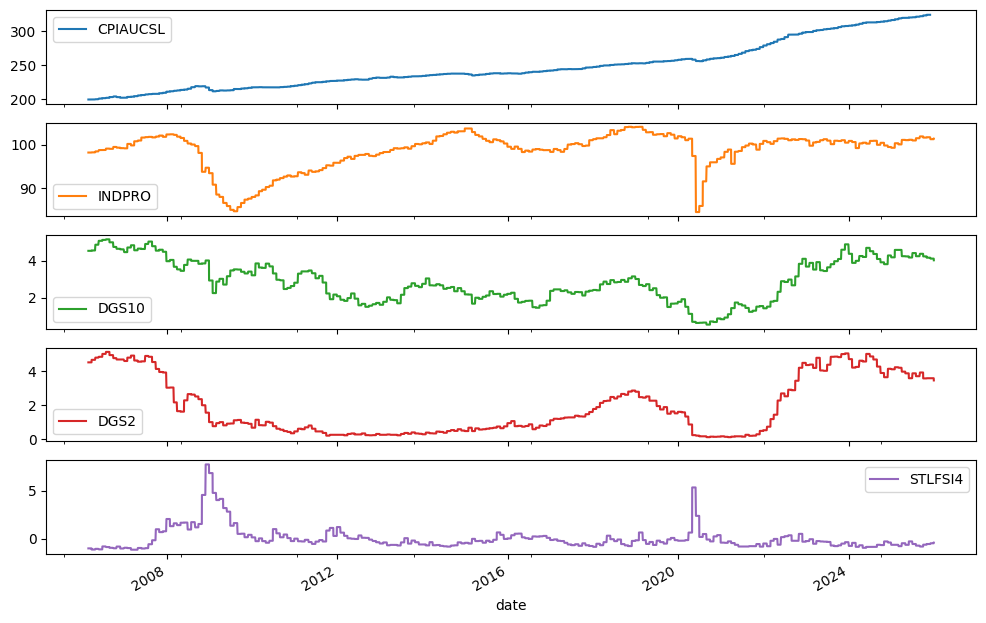

In [61]:
macro_cols = ["CPIAUCSL", "INDPRO", "DGS10", "DGS2", "STLFSI4"]
aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl_macro = aapl[macro_cols]

aapl_macro.plot(subplots=True, figsize=(12,8))
plt.show()


### NaN Rates

In [78]:
macro_na_rates = df[macro_cols].isna().mean().sort_values(ascending=False)
display(macro_na_rates)

CPIAUCSL    0.011629
INDPRO      0.007573
DGS10       0.007573
DGS2        0.007573
STLFSI4     0.007573
dtype: float64

CPIAUCSL shows slightly higher NaN rates than the other macro series because it is monthly and its
first effective value can appear later in the window once the publication lag is applied. The daily
and weekly series (DGS10/DGS2/STLFSI4) retain more continuous coverage after monthly resampling, so
their NaN rate mainly reflects the initial one-month lag. These macro NaNs are expected and will be
forward-filled in preprocessing after the first valid observation.


### Macro Consistency Across Tickers


Macro series should be identical across tickers on the same date. This check flags dates where a macro
column has more than one distinct value across the cross section.

In [63]:
macro_cols = ["CPIAUCSL", "INDPRO", "DGS10", "DGS2", "STLFSI4"]
for col in macro_cols:
    if col not in df.columns:
        continue
    nuniq = df.groupby("date")[col].nunique(dropna=True)
    bad = nuniq[nuniq > 1]
    if bad.empty:
        print(f"{col}: OK (single value per date)")
    else:
        print(f"{col}: {len(bad)} dates with multiple values")


CPIAUCSL: OK (single value per date)
INDPRO: OK (single value per date)
DGS10: OK (single value per date)
DGS2: OK (single value per date)
STLFSI4: OK (single value per date)


### Changing frequency of MACROS

Each macro series should change at its expected cadence after the merge: monthly CPI/INDPRO, daily yields resampled to month-end, and weekly STLFSI4 resampled to month-end. All series use a 30-day lag before they become effective.


In [ ]:
macro_cols = ["CPIAUCSL", "INDPRO", "DGS10", "DGS2", "STLFSI4"]
appl_macro = df[df["ticker"]=="AAPL"][["date"] + macro_cols]

for col in macro_cols:
  non_nan_dates = appl_macro[appl_macro[col].notna()]["date"].unique()
  old_val = None
  count = 0
  for date in non_nan_dates:
    val = appl_macro.loc[appl_macro["date"]==date, col].iloc[0]
    if old_val is not None and val != old_val:
      print(f"Value changed for {col} on {date.date()}: {old_val} -> {val}")
      count += 1
    old_val = val
    if count >= 4:
      print("...")
      break


Value changed for CPIAUCSL on 2006-03-30: 199.3 -> 199.4
Value changed for CPIAUCSL on 2006-05-01: 199.4 -> 199.7
Value changed for CPIAUCSL on 2006-05-30: 199.7 -> 200.7
Value changed for CPIAUCSL on 2006-06-30: 200.7 -> 201.3
...
Value changed for INDPRO on 2006-03-30: 98.1999 -> 98.2413
Value changed for INDPRO on 2006-05-01: 98.2413 -> 98.4628
Value changed for INDPRO on 2006-05-30: 98.4628 -> 98.7618
Value changed for INDPRO on 2006-06-30: 98.7618 -> 98.7869
...
Value changed for DGS10 on 2006-03-30: 4.53 -> 4.55
Value changed for DGS10 on 2006-05-01: 4.55 -> 4.86
Value changed for DGS10 on 2006-05-30: 4.86 -> 5.07
Value changed for DGS10 on 2006-06-30: 5.07 -> 5.12
...
Value changed for DGS2 on 2006-03-30: 4.54 -> 4.69
Value changed for DGS2 on 2006-05-01: 4.69 -> 4.82
Value changed for DGS2 on 2006-05-30: 4.82 -> 4.87
Value changed for DGS2 on 2006-06-30: 4.87 -> 5.04
...
Value changed for STLFSI4 on 2006-03-30: -0.9958 -> -1.1169
Value changed for STLFSI4 on 2006-05-01: -1.1169

## Save Manifest

Write a dataset manifest only after sanity checks pass.

In [65]:
from src.config.io import build_manifest_from_df, save_manifest
from notebooks.params import CFG, OUT_DIR

manifest = build_manifest_from_df(CFG, df, stages=["panel_raw"])
save_manifest(manifest, OUT_DIR)


PosixPath('/Users/igordragone/projects/hybrid-stock-prediction-thesis/data/processed/datasets/master_45t_20y/manifest.json')